### **Unemployment in India**

### **1.Load Library**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV,KFold,cross_validate,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.metrics import root_mean_squared_error,mean_absolute_error,r2_score
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,HistGradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
pd.set_option('display.float_format', '{:,.6f}'.format)
Target = "employed"



### **2.Load DataSet**

In [2]:
df = pd.read_csv("Unemployment in India.csv")

In [3]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.650000,"11,999,139.000000",43.240000,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.050000,"11,755,881.000000",42.050000,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.750000,"12,086,707.000000",43.500000,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.320000,"12,285,693.000000",43.970000,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.170000,"12,256,762.000000",44.680000,Rural


### **3.Exploratory Data Analysis**

In [4]:
df.columns = df.columns.str.lower()

In [5]:
df.columns.to_list()

['region',
 ' date',
 ' frequency',
 ' estimated unemployment rate (%)',
 ' estimated employed',
 ' estimated labour participation rate (%)',
 'area']

In [6]:
df.columns

Index(['region', ' date', ' frequency', ' estimated unemployment rate (%)',
       ' estimated employed', ' estimated labour participation rate (%)',
       'area'],
      dtype='object')

In [7]:
df.columns = df.columns.str.strip()

In [8]:
df.columns

Index(['region', 'date', 'frequency', 'estimated unemployment rate (%)',
       'estimated employed', 'estimated labour participation rate (%)',
       'area'],
      dtype='object')

In [9]:
df.rename(
    columns = {
        "estimated unemployment rate (%)":"unemployment_rate (%)",
        "estimated employed":"employed",
        "estimated labour participation rate (%)":"labour_participate_rate (%)"
    },inplace = True
)

In [10]:
df.columns

Index(['region', 'date', 'frequency', 'unemployment_rate (%)', 'employed',
       'labour_participate_rate (%)', 'area'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   region                       740 non-null    object 
 1   date                         740 non-null    object 
 2   frequency                    740 non-null    object 
 3   unemployment_rate (%)        740 non-null    float64
 4   employed                     740 non-null    float64
 5   labour_participate_rate (%)  740 non-null    float64
 6   area                         740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [12]:
df.shape

(768, 7)

In [13]:
for col in df.columns:
    print(df[col].value_counts())

region
Andhra Pradesh      28
Bihar               28
Chhattisgarh        28
Delhi               28
Karnataka           28
Gujarat             28
Haryana             28
Himachal Pradesh    28
Jharkhand           28
Maharashtra         28
Madhya Pradesh      28
Kerala              28
West Bengal         28
Uttar Pradesh       28
Tripura             28
Odisha              28
Rajasthan           28
Punjab              28
Telangana           28
Tamil Nadu          28
Uttarakhand         27
Meghalaya           27
Assam               26
Puducherry          26
Goa                 24
Jammu & Kashmir     21
Sikkim              17
Chandigarh          12
Name: count, dtype: int64
date
31-10-2019    55
30-11-2019    55
30-06-2019    54
31-07-2019    54
31-05-2019    54
31-08-2019    53
31-01-2020    53
31-12-2019    53
29-02-2020    53
30-09-2019    52
31-03-2020    52
30-04-2020    51
31-05-2020    51
30-06-2020    50
Name: count, dtype: int64
frequency
Monthly     381
 Monthly    359
Name: count,

In [14]:
df["date"] = pd.to_datetime(df["date"])
df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year

C:\Users\Asus\AppData\Local\Temp\ipykernel_261708\264822659.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"])


In [15]:
print(df["date"].dtype)

datetime64[ns]


In [16]:
df.dtypes

region                                 object
date                           datetime64[ns]
frequency                              object
unemployment_rate (%)                 float64
employed                              float64
labour_participate_rate (%)           float64
area                                   object
day                                   float64
month                                 float64
year                                  float64
dtype: object

In [17]:
for col in df.columns:
    print(df[col].value_counts().head(20))

region
Andhra Pradesh      28
Bihar               28
Chhattisgarh        28
Delhi               28
Karnataka           28
Gujarat             28
Haryana             28
Himachal Pradesh    28
Jharkhand           28
Maharashtra         28
Madhya Pradesh      28
Kerala              28
West Bengal         28
Uttar Pradesh       28
Tripura             28
Odisha              28
Rajasthan           28
Punjab              28
Telangana           28
Tamil Nadu          28
Name: count, dtype: int64
date
2019-10-31    55
2019-11-30    55
2019-06-30    54
2019-07-31    54
2019-05-31    54
2019-08-31    53
2020-01-31    53
2019-12-31    53
2020-02-29    53
2019-09-30    52
2020-03-31    52
2020-04-30    51
2020-05-31    51
2020-06-30    50
Name: count, dtype: int64
frequency
Monthly     381
 Monthly    359
Name: count, dtype: int64
unemployment_rate (%)
0.000000     11
3.310000      4
5.350000      3
3.660000      3
20.000000     3
3.730000      3
3.570000      3
6.110000      3
6.460000      3
12.5

In [18]:
df = df.drop(columns = ["date","frequency"])

In [19]:
df.columns

Index(['region', 'unemployment_rate (%)', 'employed',
       'labour_participate_rate (%)', 'area', 'day', 'month', 'year'],
      dtype='object')

In [20]:
df.shape

(768, 8)

**Visualization**

In [21]:
df.dtypes

region                          object
unemployment_rate (%)          float64
employed                       float64
labour_participate_rate (%)    float64
area                            object
day                            float64
month                          float64
year                           float64
dtype: object

In [22]:
df.head()

,region,unemployment_rate (%),employed,labour_participate_rate (%),area,day,month,year
0,Andhra Pradesh,3.650000,"11,999,139.000000",43.240000,Rural,31.000000,5.000000,"2,019.000000"
1,Andhra Pradesh,3.050000,"11,755,881.000000",42.050000,Rural,30.000000,6.000000,"2,019.000000"
2,Andhra Pradesh,3.750000,"12,086,707.000000",43.500000,Rural,31.000000,7.000000,"2,019.000000"
3,Andhra Pradesh,3.320000,"12,285,693.000000",43.970000,Rural,31.000000,8.000000,"2,019.000000"
4,Andhra Pradesh,5.170000,"12,256,762.000000",44.680000,Rural,30.000000,9.000000,"2,019.000000"


In [23]:
num = df.select_dtypes(include = {np.number}).columns.to_list()
cat =  df.select_dtypes(exclude = {np.number}).columns.to_list()

print(num)
print(cat)

['unemployment_rate (%)', 'employed', 'labour_participate_rate (%)', 'day', 'month', 'year']
['region', 'area']


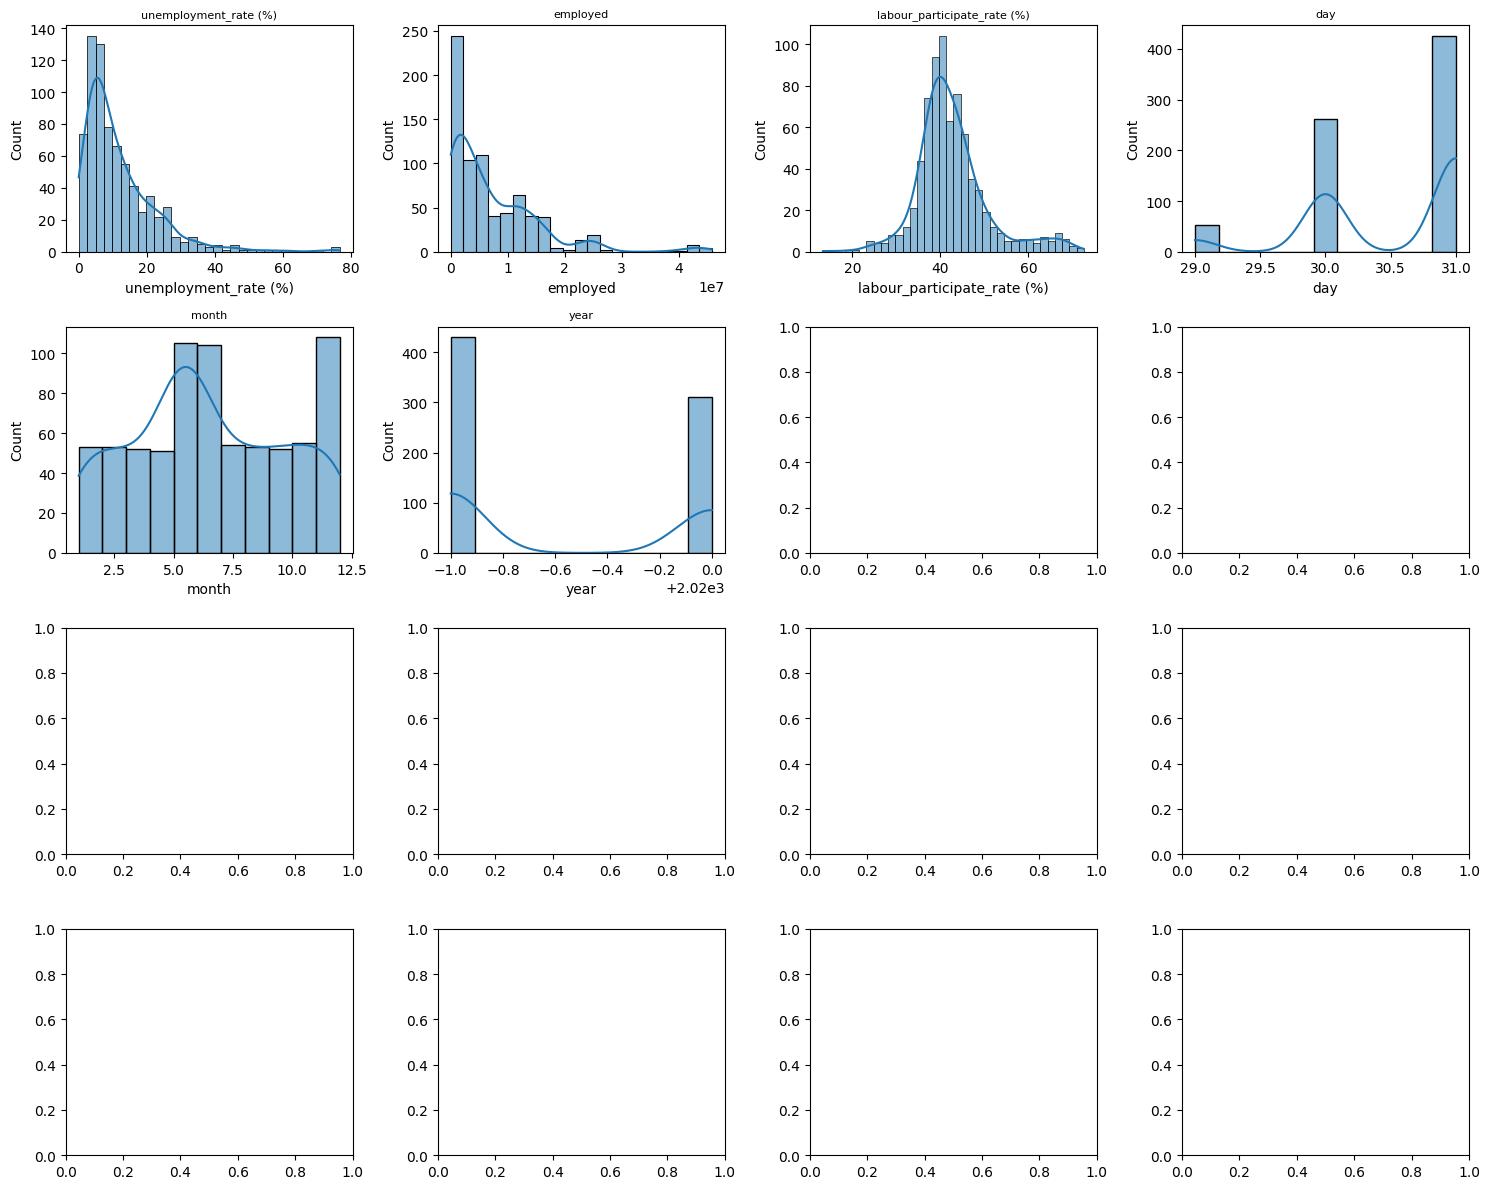

In [24]:
# HistPlot 
fig,axes = plt.subplots(4,4,figsize = (15,12))
axes = axes.flatten()

for i,col in enumerate(num):
    sns.histplot(df[col],kde = True,ax = axes[i])
    axes[i].set_title(col,fontsize = 8)
plt.tight_layout()
plt.show()

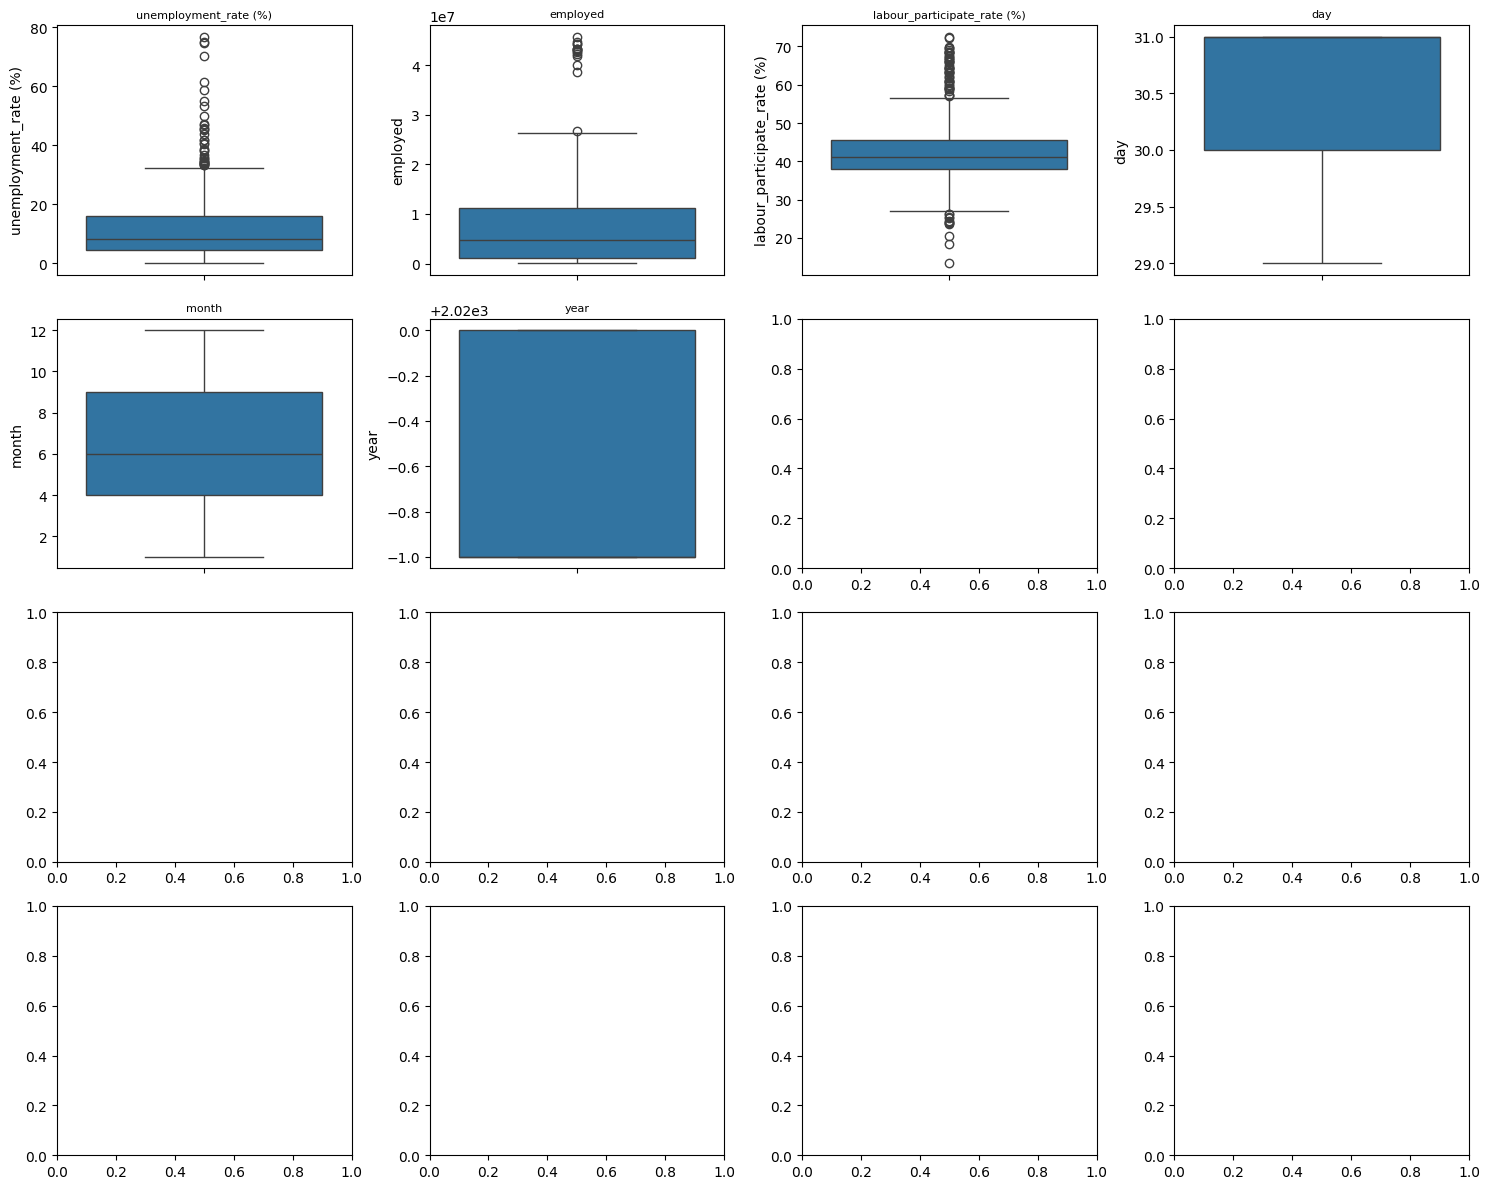

In [25]:
# HistPlot 
fig,axes = plt.subplots(4,4,figsize = (15,12))
axes = axes.flatten()

for i,col in enumerate(num):
    sns.boxplot(df[col],ax = axes[i])
    axes[i].set_title(col,fontsize = 8)
plt.tight_layout()
plt.show()

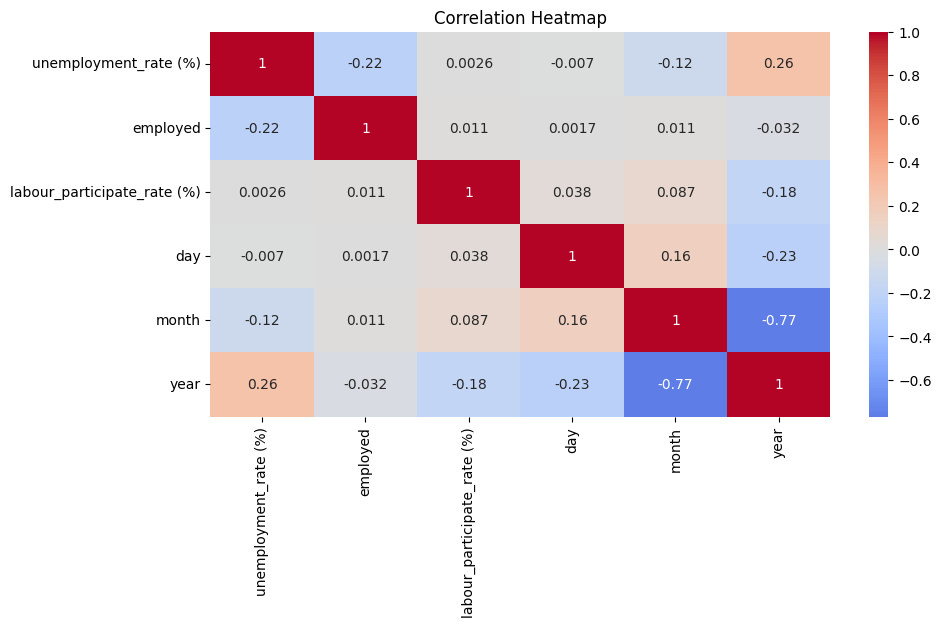

In [26]:
# identify presence of highly correlated columns & feature relationships
plt.figure(figsize=(10, 5))
sns.heatmap(
    df[num].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

From our EDA process I got these things.
1.It has no missing values.
2.It has no outliers for capped

### **4.Preprocessing**

In [27]:
df = df.dropna(subset=["employed"])

In [28]:
X = df.drop(columns = Target)
y = df[Target]

In [29]:
X.shape

(740, 7)

In [30]:
y.shape

(740,)

**4.1 Split The data**

In [31]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [32]:
print("Shape of X dataset:",X.shape)
print("Shape of X_train dataset:",X_train.shape)
print("Shape of X_test dataset:",X_test.shape)
print("Shape of y_train dataset:",y_train.shape)
print("Shape of y_test dataset:",y_test.shape)

Shape of X dataset: (740, 7)
Shape of X_train dataset: (592, 7)
Shape of X_test dataset: (148, 7)
Shape of y_train dataset: (592,)
Shape of y_test dataset: (148,)


In [33]:
X_train["region"].value_counts()

region
Odisha              26
Jharkhand           26
Maharashtra         26
Punjab              25
Himachal Pradesh    24
Madhya Pradesh      24
Chhattisgarh        23
Tamil Nadu          23
Rajasthan           22
Karnataka           22
Bihar               22
Tripura             22
Kerala              22
Gujarat             22
Assam               22
Telangana           22
Uttar Pradesh       22
Haryana             22
Andhra Pradesh      21
West Bengal         20
Uttarakhand         20
Jammu & Kashmir     19
Puducherry          19
Meghalaya           18
Delhi               17
Sikkim              17
Goa                 14
Chandigarh          10
Name: count, dtype: int64

In [34]:
X_train.head()

,region,unemployment_rate (%),labour_participate_rate (%),area,day,month,year
244,Punjab,12.210000,45.790000,Rural,30.000000,6.000000,"2,019.000000"
563,Madhya Pradesh,7.380000,37.670000,Urban,31.000000,7.000000,"2,019.000000"
537,Karnataka,3.570000,39.000000,Urban,30.000000,9.000000,"2,019.000000"
500,Himachal Pradesh,23.770000,49.690000,Urban,31.000000,10.000000,"2,019.000000"
135,Jharkhand,9.980000,39.660000,Rural,31.000000,7.000000,"2,019.000000"


**4.2 Preprocess Pipeline**

In [35]:
print(num)
print("="*50)
print(cat)

['unemployment_rate (%)', 'employed', 'labour_participate_rate (%)', 'day', 'month', 'year']
['region', 'area']


In [36]:
numerical_feature = X_train.select_dtypes(include = {np.number}).columns.to_list()
categorical_feature = X_train.select_dtypes(exclude = {np.number}).columns.to_list()
num_pip = Pipeline(
    steps = [
        ("imputer",SimpleImputer(strategy = "median")),
        ("scaler",StandardScaler())
        
    ]
)
cat_pip = Pipeline(
    steps = [
        ("imputer",SimpleImputer(strategy = "most_frequent")),
        ("OneHotEncoder",OneHotEncoder(handle_unknown = "ignore",sparse_output = False))
    ]
)
preprocess = ColumnTransformer(
    transformers  = [
    ("num",num_pip,numerical_feature),
    ("cat",cat_pip,categorical_feature)    
    ]
    
)

### **5.BaseLine Model**

In [37]:
baseline = Pipeline(
    steps = [
        ("preprocess",preprocess),
        ("model",LinearRegression())
    ]
)

In [38]:
baseline.fit(X_train,y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


**Training report**

In [39]:
print("Training rmse:",root_mean_squared_error(y_train,baseline.predict(X_train)))
print("Training mae:",mean_absolute_error(y_train,baseline.predict(X_train)))
print("Training r2_score:",r2_score(y_train,baseline.predict(X_train)))

Training rmse: 3372092.741163366
Training mae: 2321201.0056187073
Training r2_score: 0.8236108422832936


In [40]:
print("Test rmse:",root_mean_squared_error(y_test,baseline.predict(X_test)))
print("Test mae:",mean_absolute_error(y_test,baseline.predict(X_test)))
print("Test r2_score:",r2_score(y_test,baseline.predict(X_test)))

Test rmse: 4056769.1723954934
Test mae: 3042181.6274439967
Test r2_score: 0.7601035184410082


### **6.HyperTune Model**

In [41]:
scoring = {
    "rmse":"neg_root_mean_square_error",
    "mae":"mean_absolute_error",
    "r2":"r2"
}

In [42]:
k = 5
cv = KFold(n_splits = k,shuffle = True,random_state = 42)

In [43]:
models = {
    "LinearRegression":LinearRegression(),
    "Ridge":Ridge(max_iter = 10000),
    "Lasso":Lasso(max_iter = 10000),
    "DecisionTreeRegressor":DecisionTreeRegressor(random_state = 42),
    "RandomForestRegressor":RandomForestRegressor(random_state = 42),
    "HistGradientBoostingRegressor":HistGradientBoostingRegressor(random_state = 42),
    "XGBRegressor":XGBRegressor(objective="reg:squarederror",random_state = 42)
}

In [44]:
result = []

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocess),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        scoring = scoring,
        cv = cv,
        n_jobs = 1
    )

    result.append({
        "name": name,
        "cv_rmse": -scores["test_rmse"].mean(),
        "cv_mae": -scores["test_mae"].mean(),
        "cv_r2": scores["test_r2"].mean()
    })

cv_results = pd.DataFrame(result).sort_values("cv_rmse")

print("=== CV Model Comparison ===")
print(cv_results)

C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.772e+14, tolerance: 2.929e+12
  model = cd_fast.enet_coordinate_descent(
C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.778e+14, tolerance: 3.184e+12
  model = cd_fast.enet_coordinate_descent(
C:\Users\Asus\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale 

=== CV Model Comparison ===
                            name          cv_rmse           cv_mae    cv_r2
6                   XGBRegressor 1,262,261.216211   734,185.619050 0.970335
4          RandomForestRegressor 1,477,350.309323   849,165.768929 0.962756
3          DecisionTreeRegressor 1,856,477.178811   772,119.526763 0.925272
2                          Lasso 3,623,223.339762 2,486,708.071399 0.788466
0               LinearRegression 3,623,223.542993 2,486,708.857138 0.788466
1                          Ridge 3,627,568.194095 2,487,983.318304 0.789441
5  HistGradientBoostingRegressor 6,675,404.995361 4,296,479.346112 0.294203


In [45]:
print("Best Model:",cv_results.iloc[0])

Best Model: name          XGBRegressor
cv_rmse   1,262,261.216211
cv_mae      734,185.619050
cv_r2             0.970335
Name: 6, dtype: object


### **Hyper parameter tuning**

In [46]:
xgb_pipeline = Pipeline (
    steps = [
    ("preprocess",preprocess),
    ("model",XGBRegressor(random_state = 42))
    ]
    
)

In [47]:
param_grid = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma": [0, 0.1, 0.2]
}

In [48]:
search_cv = RandomizedSearchCV(
    estimator = xgb_pipeline,
    param_distributions = param_grid,
    cv = cv,
    scoring = "neg_root_mean_squared_error",
    n_jobs = 1,
    verbose = True
    
)

In [49]:
search_cv.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.7, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], ...}"
,n_iter,10
,scoring,'neg_root_mean_squared_error'
,n_jobs,1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [50]:
print("Best scores:",-search_cv.best_score_)
print("Best Paramd :",search_cv.best_params_)

Best scores: 1138416.783637741
Best Paramd : {'model__subsample': 1.0, 'model__n_estimators': 300, 'model__min_child_weight': 5, 'model__max_depth': 7, 'model__learning_rate': 0.1, 'model__gamma': 0.1, 'model__colsample_bytree': 1.0}


### **Retrain with our best model**

In [51]:
XGB_best = Pipeline(
    steps = [
        ("preprocess",preprocess),
        ("model",XGBRegressor(
            subsample = 0.7,
            n_estimators = 300,
            min_child_weight = 3,
            max_depth = 5,
            learning_rate = 0.1,
            gamma = 0.1,
            colsample_bytree = 0.7            
        ))
    ]
)

In [52]:
XGB_best.fit(X_train,y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### **final Evaluation**

In [53]:
train_final_pred = XGB_best.predict(X_train)

train_final_rmse = root_mean_squared_error(y_train, train_final_pred)
train_final_mae = mean_absolute_error(y_train, train_final_pred)
train_final_r2 = r2_score(y_train, train_final_pred)

print("\n=== FINAL MODEL (Tuned XGB_best) Train Performance ===")
print(f"RMSE: {train_final_rmse:.3f}")
print(f"MAE : {train_final_mae:.3f}")
print(f"R2  : {train_final_r2:.3f}")


=== FINAL MODEL (Tuned XGB_best) Train Performance ===
RMSE: 256231.440
MAE : 178456.187
R2  : 0.999


In [54]:
test_final_pred = XGB_best.predict(X_test)

test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_final_pred)

print("\n=== FINAL MODEL (Tuned XGB_best) Test Performance ===")
print(f"RMSE: {test_final_rmse:.3f}")
print(f"MAE : {test_final_mae:.3f}")
print(f"R2  : {test_final_r2:.3f}")


=== FINAL MODEL (Tuned XGB_best) Test Performance ===
RMSE: 890781.941
MAE : 596470.108
R2  : 0.988


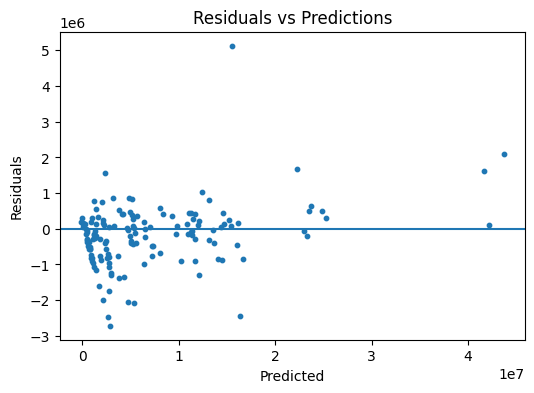

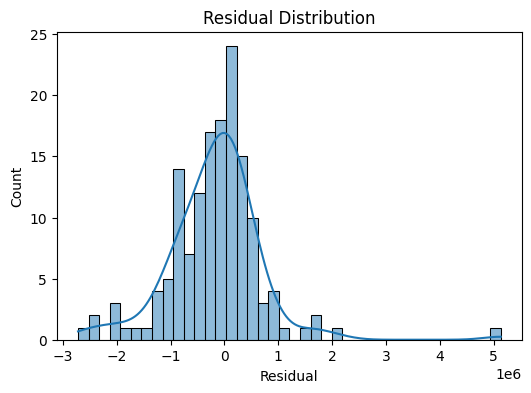

In [55]:
# residual plot
residuals = y_test - test_final_pred

plt.figure(figsize=(6, 4))
plt.scatter(test_final_pred, residuals, s=10)
plt.axhline(0)
plt.title("Residuals vs Predictions")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

In [56]:
X_train.dtypes

region                          object
unemployment_rate (%)          float64
labour_participate_rate (%)    float64
area                            object
day                            float64
month                          float64
year                           float64
dtype: object

### **Build a Predictive System**

In [57]:
def unemployment_prediction(model, region: str,
                        unemployment_rate: float,
                        labour_participate_rate: float,
                        area: str,
                        day: float,
                        month: float,
                        year: float):

    input_data = pd.DataFrame([{
        "region": region,
        "unemployment_rate (%)": unemployment_rate,
        "labour_participate_rate (%)": labour_participate_rate,
        "area": area,
        "day": day,
        "month": month,
        "year": year
    }])

    return model.predict(input_data)[0]

In [58]:
price = unemployment_prediction(
    model=XGB_best,
    region="Andhra Pradesh",
    unemployment_rate=3.050000	,
    labour_participate_rate=42.050000,
    area="Rural",
    day=30.000000,
    month=6,
    year=2019
)

print(price)

11873231.0


In [59]:
print(XGB_best.feature_names_in_)

['region' 'unemployment_rate (%)' 'labour_participate_rate (%)' 'area'
 'day' 'month' 'year']


In [60]:
df.head(2)

,region,unemployment_rate (%),employed,labour_participate_rate (%),area,day,month,year
0,Andhra Pradesh,3.650000,"11,999,139.000000",43.240000,Rural,31.000000,5.000000,"2,019.000000"
1,Andhra Pradesh,3.050000,"11,755,881.000000",42.050000,Rural,30.000000,6.000000,"2,019.000000"


### **Model**

In [61]:
import joblib

In [62]:
joblib.dump(XGB_best,"xgb_model.joblib")

['xgb_model.joblib']